<a href="https://colab.research.google.com/github/np03cs4a230349-stack/AI-ML/blob/main/2408983_Abhiral_Pradhan_code_text_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# INSTALL REQUIRED LIBRARIES

!pip install contractions wordcloud gensim nltk -q

# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import re
import contractions
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from collections import Counter

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

from gensim.models import Word2Vec

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.7 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
# LOAD DATASET

df = pd.read_csv('/content/drive/MyDrive/AI-ML/Portfolio/truevsfakenews.csv')

# Display first 5 rows
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

                                                text label
0  WASHINGTON (Reuters) - The Republican and Demo...  true
1  Women should get as far away from Oklahoma as ...  fake
2  Another huge crowd of Americans tuned in last ...  fake
3  Donald Trump is desperate to stop the investig...  fake
4  (Reuters) - Planned Parenthood, the U.S. medic...  true

Dataset Shape:
(20000, 2)

Columns:
Index(['text', 'label'], dtype='object')


In [ ]:
# 4. CHECK TARGET COLUMN

text_column = df.columns[0]
target_column = df.columns[1]

print("\nText Column:", text_column)
print("Target Column:", target_column)


Text Column: text
Target Column: label


In [ ]:
# TEXT PREPROCESSING

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    # Convert to string
    text = str(text)

    # Lowercase
    text = text.lower()

    # Expand contractions
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove mentions
    text = re.sub(r'@\w+', '', text)

    # Remove hashtags
    text = re.sub(r'#\w+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Apply cleaning
df['cleaned_text'] = df[text_column].apply(clean_text)

print("\nCleaned Text Sample:")
print(df['cleaned_text'].head())


Cleaned Text Sample:
0    washington reuters republican democratic leade...
1    woman get far away oklahoma soon possible chri...
2    another huge crowd american tuned last week re...
3    donald trump desperate stop investigation dirt...
4    reuters planned parenthood yous medical servic...
Name: cleaned_text, dtype: object


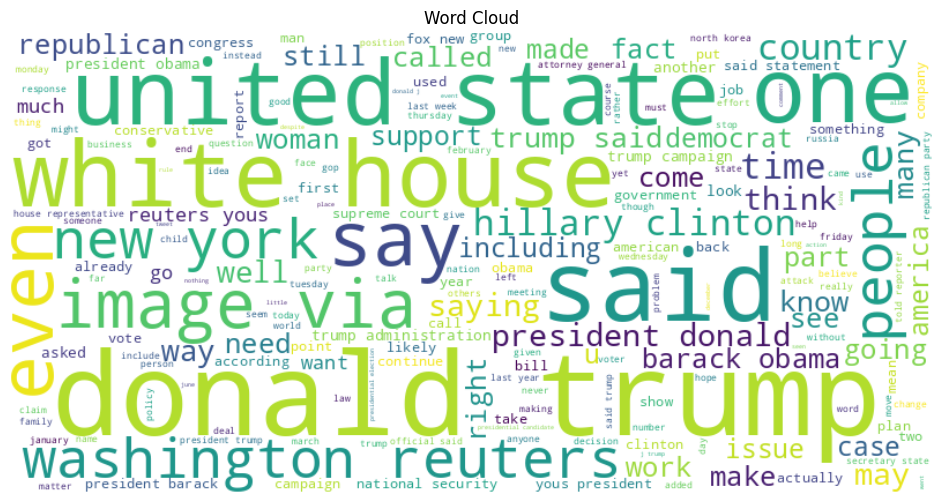

In [ ]:
# WORD CLOUD VISUALIZATION

all_words = " ".join(df['cleaned_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()


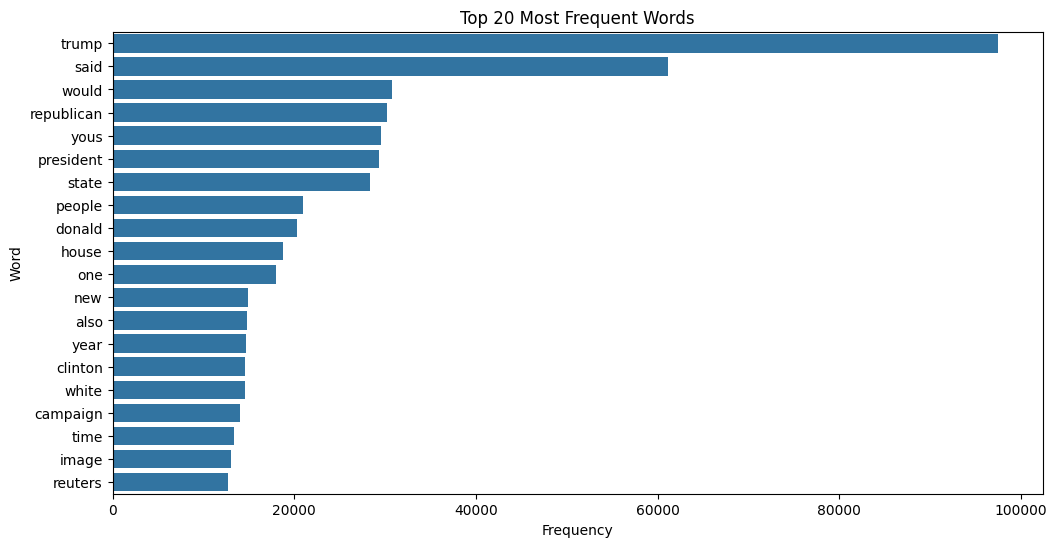

In [ ]:
# MOST FREQUENT WORDS

words = all_words.split()

word_freq = Counter(words)

common_words = word_freq.most_common(20)

freq_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(12,6))
sns.barplot(x='Frequency', y='Word', data=freq_df)
plt.title("Top 20 Most Frequent Words")
plt.show()

In [ ]:
# ENCODE LABELS

if df[target_column].dtype == 'object':
    df[target_column] = df[target_column].astype('category').cat.codes

print(df[target_column].value_counts())

label
1    10000
0    10000
Name: count, dtype: int64


In [ ]:
# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    df['cleaned_text'],
    df[target_column],
    test_size=0.2,
    random_state=42,
    stratify=df[target_column]
)

print("\nTraining Size:", len(X_train))
print("Testing Size:", len(X_test))


Training Size: 16000
Testing Size: 4000


In [ ]:
# TOKENIZATION

MAX_WORDS = 10000

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
# 11. PADDING
# Percentile-based padding length
sequence_lengths = [len(seq) for seq in X_train_seq]

MAX_LEN = int(np.percentile(sequence_lengths, 95))

print("\nMax Sequence Length (95th percentile):", MAX_LEN)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)



Max Sequence Length (95th percentile): 493


In [ ]:
# MODEL 1 - SIMPLE RNN

embedding_dim = 128

model1 = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=embedding_dim,
        input_length=MAX_LEN
    ),

    SimpleRNN(64),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model1.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TRAIN MODEL 1

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history1 = model1.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 63s 157ms/step - accuracy: 0.5171 - loss: 0.7059 - val_accuracy: 0.5425 - val_loss: 0.6821
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 78s 149ms/step - accuracy: 0.5198 - loss: 0.7085 - val_accuracy: 0.5437 - val_loss: 0.6773
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 59s 148ms/step - accuracy: 0.5265 - loss: 0.6872 - val_accuracy: 0.5466 - val_loss: 0.6764
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 62s 155ms/step - accuracy: 0.5255 - loss: 0.6792 - val_accuracy: 0.5469 - val_loss: 0.6749
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 79s 148ms/step - accuracy: 0.5344 - loss: 0.6752 - val_accuracy: 0.4997 - val_loss: 0.6772
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 82s 149ms/step - accuracy: 0.5311 - loss: 0.6802 - val_accuracy: 0.5000 - val_loss: 0.6847
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 60s 149ms/step - accuracy: 0.5288 - loss: 0.6749 - val_accuracy: 0.4978 - val_loss: 0.6873


In [ ]:
#  MODEL 2 - LSTM

model2 = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=embedding_dim,
        input_length=MAX_LEN
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  TRAIN MODEL 2

history2 = model2.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
    )

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 124s 303ms/step - accuracy: 0.5275 - loss: 0.6838 - val_accuracy: 0.5472 - val_loss: 0.6663
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 143s 305ms/step - accuracy: 0.5366 - loss: 0.6717 - val_accuracy: 0.5000 - val_loss: 0.6796
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 119s 296ms/step - accuracy: 0.5420 - loss: 0.6629 - val_accuracy: 0.5562 - val_loss: 0.6604
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 120s 299ms/step - accuracy: 0.7816 - loss: 0.4440 - val_accuracy: 0.9703 - val_loss: 0.1111
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 140s 293ms/step - accuracy: 0.9801 - loss: 0.1014 - val_accuracy: 0.9841 - val_loss: 0.0779
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 142s 294ms/step - accuracy: 0.9721 - loss: 0.1042 - val_accuracy: 0.9897 - val_loss: 0.0465
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 146s 303ms/step - accuracy: 0.9847 - loss: 0.0698 - val_accuracy: 0.9309 - val_loss: 0.1761
Epoch 8/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 121s 301ms/step - accuracy: 0.9760 -

In [ ]:
# WORD2VEC EMBEDDINGS

sentences = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)
word_index = tokenizer.word_index

embedding_dim_w2v = 100

embedding_matrix = np.zeros(
    (MAX_WORDS, embedding_dim_w2v)
)

for word, i in word_index.items():

    if i >= MAX_WORDS:
        continue

    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]


In [ ]:
#  MODEL 3 - LSTM + WORD2VEC

model3 = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model3.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model3.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [ ]:
# 18. TRAIN MODEL 3

history3 = model3.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 80s 199ms/step - accuracy: 0.8731 - loss: 0.3067 - val_accuracy: 0.9697 - val_loss: 0.1379
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 96s 235ms/step - accuracy: 0.9556 - loss: 0.1762 - val_accuracy: 0.9725 - val_loss: 0.1278
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 124s 192ms/step - accuracy: 0.9621 - loss: 0.1546 - val_accuracy: 0.9647 - val_loss: 0.1409


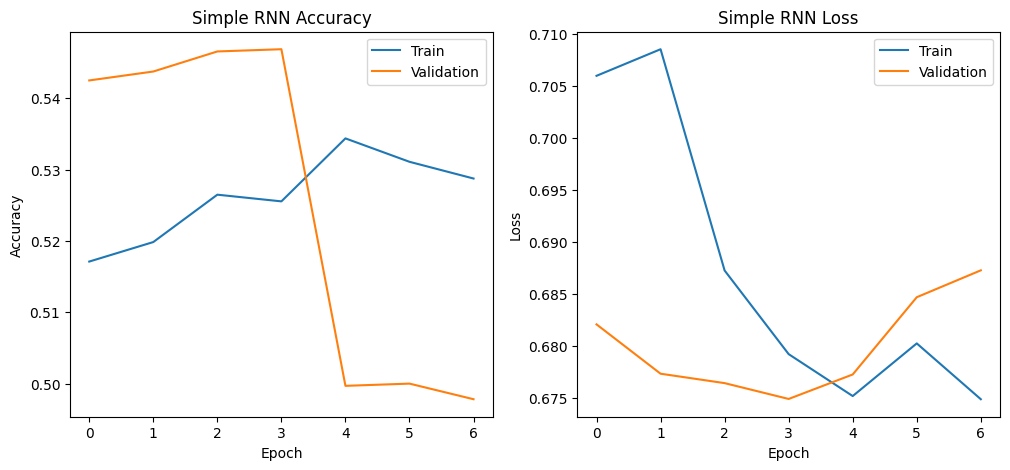

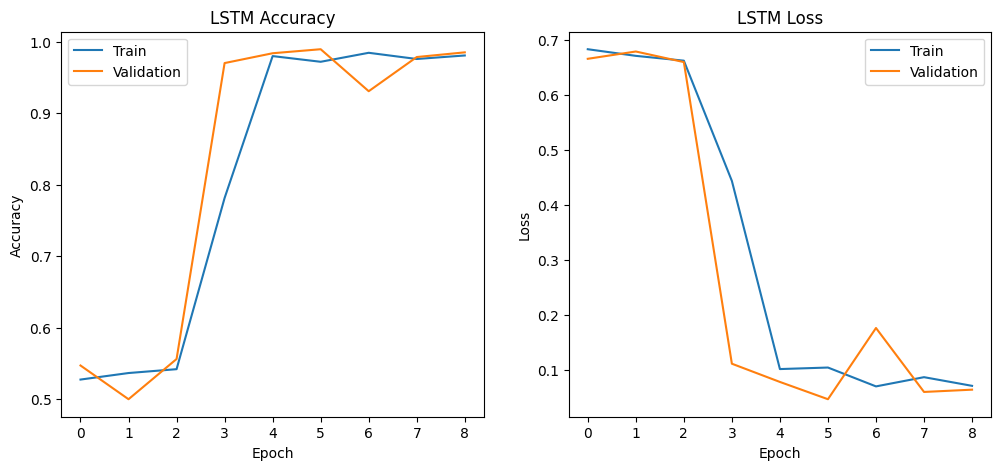

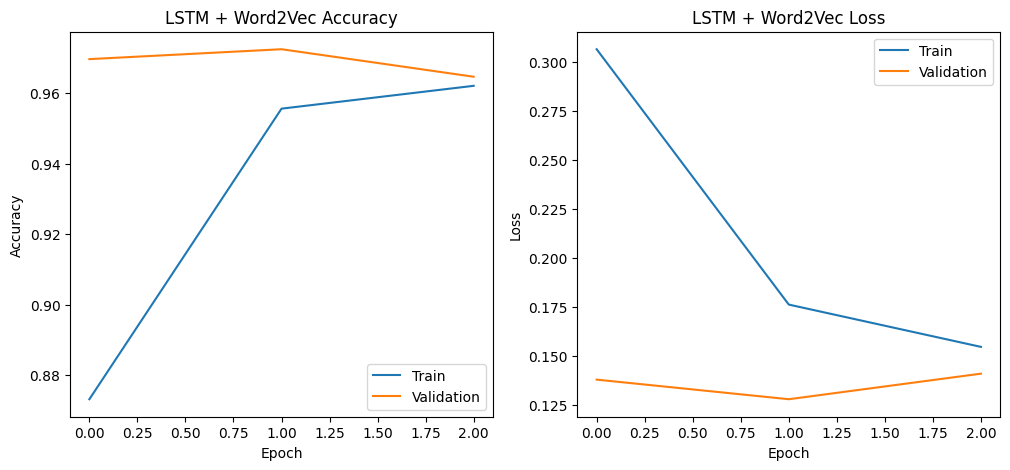

In [ ]:
#  PLOT TRAINING HISTORY

def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(['Train', 'Validation'])

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title(f'{title} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation'])

    plt.show()

plot_history(history1, "Simple RNN")
plot_history(history2, "LSTM")
plot_history(history3, "LSTM + Word2Vec")


In [ ]:

# 20. EVALUATION FUNCTION

def evaluate_model(model, X_test, y_test, model_name):

    y_pred_prob = model.predict(X_test)

    y_pred = (y_pred_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)

    print(f"\n{model_name} Accuracy: {acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return y_pred

125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step

Simple RNN Accuracy: 0.5433


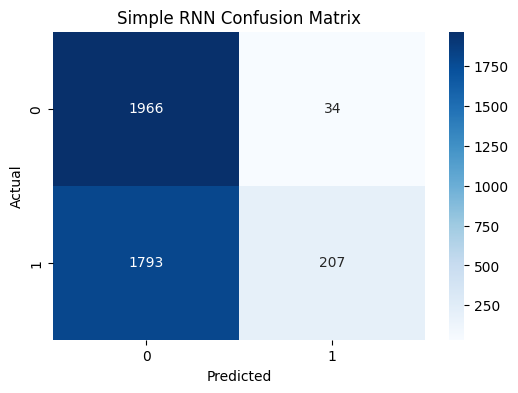


Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.98      0.68      2000
           1       0.86      0.10      0.18      2000

    accuracy                           0.54      4000
   macro avg       0.69      0.54      0.43      4000
weighted avg       0.69      0.54      0.43      4000

125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step

LSTM Accuracy: 0.9865


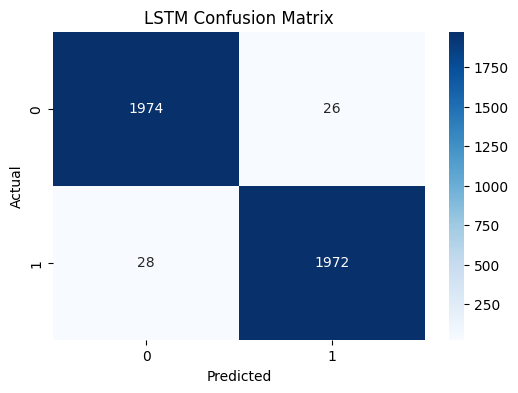


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2000
           1       0.99      0.99      0.99      2000

    accuracy                           0.99      4000
   macro avg       0.99      0.99      0.99      4000
weighted avg       0.99      0.99      0.99      4000

125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 69ms/step

LSTM + Word2Vec Accuracy: 0.9607


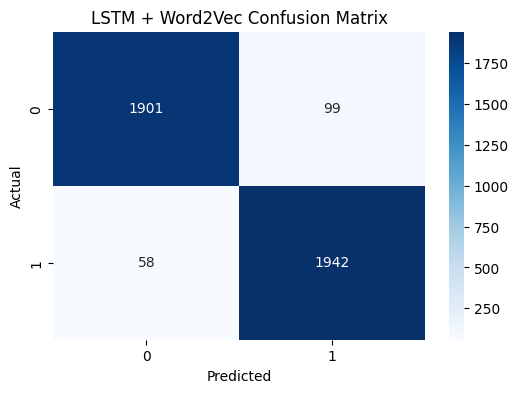


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      2000
           1       0.95      0.97      0.96      2000

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



In [ ]:
# EVALUATE ALL MODELS

pred1 = evaluate_model(
    model1,
    X_test_pad,
    y_test,
    "Simple RNN"
)

pred2 = evaluate_model(
    model2,
    X_test_pad,
    y_test,
    "LSTM"
)

pred3 = evaluate_model(
    model3,
    X_test_pad,
    y_test,
    "LSTM + Word2Vec"
)


             Model  Accuracy
0       Simple RNN   0.54325
1             LSTM   0.98650
2  LSTM + Word2Vec   0.96075


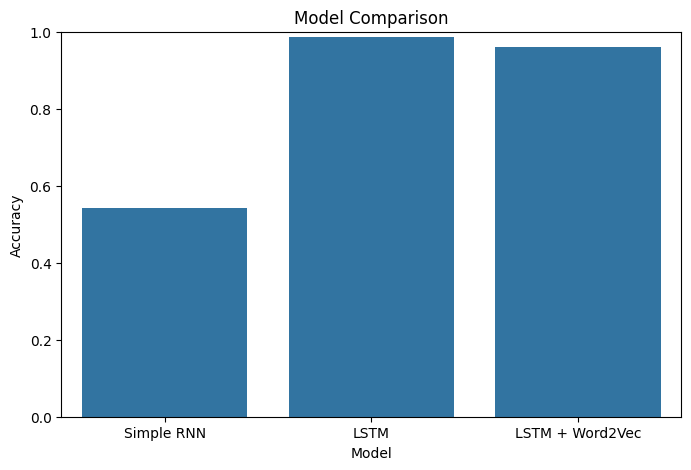

In [ ]:
#  COMPARE MODEL PERFORMANCE
acc1 = accuracy_score(y_test, pred1)
acc2 = accuracy_score(y_test, pred2)
acc3 = accuracy_score(y_test, pred3)

comparison_df = pd.DataFrame({
    'Model': [
        'Simple RNN',
        'LSTM',
        'LSTM + Word2Vec'
    ],
    'Accuracy': [
        acc1,
        acc2,
        acc3
    ]
})

print(comparison_df)

plt.figure(figsize=(8,5))
sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison_df
)

plt.title("Model Comparison")
plt.ylim(0,1)
plt.show()


In [ ]:
# 23. ERROR ANALYSIS

# Use best model predictions
y_pred_prob = model3.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

incorrect = np.where(y_pred != y_test_reset)[0]

print("\nMisclassified Examples:\n")

for i in incorrect[:3]:

    print("Tweet:")
    print(X_test_reset[i])

    print("\nActual Label:", y_test_reset[i])
    print("Predicted Label:", y_pred[i])

125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step

Misclassified Examples:

Tweet:
washington reuters yous treasury secretary steven mnuchin said sunday regret using government plane travel kentucky august wife view solar eclipse speak business leader calling completely justifiable mnuchins use plane taxpayer expense prompted outcry democratic lawmaker interest group spurred government watchdog begin examining whether violated travel ethic policy approved white house reason needed use plane completely justifiable said nbcs meet press program cabinet member rarely use government plane chartered aircraft domestic travel practice received significant attention wake mnuchins trip friday former health human service secretary tom price resigned outcry use private charter plane government business cost nearly mnuchin told nbc would use private plane government purpose either national security issue could get somewhere treasury department described mnuchins trip august official government travel mnuc

In [ ]:
# ============================================
# 23. ERROR ANALYSIS
# ============================================

# Use best model predictions
y_pred_prob = model3.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

X_test_reset = X_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

incorrect = np.where(y_pred != y_test_reset)[0]

print("\nMisclassified Examples:\n")

for i in incorrect[:3]:

    print("Tweet:")
    print(X_test_reset[i])

    print("\nActual Label:", y_test_reset[i])
    print("Predicted Label:", y_pred[i])

125/125 ━━━━━━━━━━━━━━━━━━━━ 17s 134ms/step

Misclassified Examples:

Tweet:
washington reuters yous treasury secretary steven mnuchin said sunday regret using government plane travel kentucky august wife view solar eclipse speak business leader calling completely justifiable mnuchins use plane taxpayer expense prompted outcry democratic lawmaker interest group spurred government watchdog begin examining whether violated travel ethic policy approved white house reason needed use plane completely justifiable said nbcs meet press program cabinet member rarely use government plane chartered aircraft domestic travel practice received significant attention wake mnuchins trip friday former health human service secretary tom price resigned outcry use private charter plane government business cost nearly mnuchin told nbc would use private plane government purpose either national security issue could get somewhere treasury department described mnuchins trip august official government travel mnu

In [ ]:
#  REAL-TIME PREDICTION FUNCTION

def predict_news(text):

    cleaned = clean_text(text)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding='post'
    )

    prediction = model3.predict(padded)[0][0]

    if prediction >= 0.5:
        return f"REAL NEWS ({prediction:.4f})"
    else:
        return f"FAKE NEWS ({prediction:.4f})"

# Example
sample = "Government announces new economic policy."

print("\nPrediction:")
print(predict_news(sample))


Prediction:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step
REAL NEWS (0.9755)


In [ ]:
# ADVANCED GRADIO GUI WITH MODEL SELECTION

!pip install gradio -q

import gradio as gr

# Prediction Function

def predict_with_model(text, selected_model):

    # Clean text
    cleaned = clean_text(text)

    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([cleaned])

    # Padding
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding='post'
    )

    # Select model
    if selected_model == "Simple RNN":
        prediction = model1.predict(padded)[0][0]

    elif selected_model == "LSTM":
        prediction = model2.predict(padded)[0][0]

    else:
        prediction = model3.predict(padded)[0][0]

    # Convert probability to label
    if prediction >= 0.5:
        label = "REAL NEWS"
    else:
        label = "FAKE NEWS"

    return f"""
    Model Used: {selected_model}

    Prediction: {label}

    Confidence Score: {prediction:.4f}
    """

# Gradio Interface

interface = gr.Interface(
    fn=predict_with_model,

    inputs=[
        gr.Textbox(
            lines=5,
            placeholder="Enter news headline or tweet here...",
            label="Input News/Tweet"
        ),

        gr.Dropdown(
            choices=[
                "Simple RNN",
                "LSTM",
                "LSTM + Word2Vec"
            ],
            value="LSTM + Word2Vec",
            label="Choose Model"
        )
    ],

    outputs=gr.Textbox(
        label="Prediction Result"
    ),

    title="Fake News Detection System",

    description="""
    Compare predictions across multiple Deep Learning models:
    - Simple RNN
    - LSTM
    - LSTM + Word2Vec
    """
)

# Launch GUI
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f75d80489a23fb2b9a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
